In [12]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import random
import matplotlib.pyplot as plt
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# Inspect the local PyTorch and CUDA runtime before building anything expensive.
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version built with PyTorch: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("PyTorch was not built with CUDA support or CUDA is not configured correctly.")


PyTorch version: 2.2.2
CUDA available: False
PyTorch was not built with CUDA support or CUDA is not configured correctly.


In [14]:
# Suppress a few noisy notebook warnings while keeping real stderr visible.
import warnings
warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")


In [15]:
# Make the repository package importable whether the notebook runs from the repo root or notebooks/.
import sys
from pathlib import Path

_cwd = Path().resolve()
_candidates = (_cwd, _cwd.parent)
for _root in _candidates:
    if (_root / 'conditional_node_field_graph_generator').exists():
        REPO_ROOT = _root.resolve()
        if str(REPO_ROOT) not in sys.path:
            sys.path.insert(0, str(REPO_ROOT))
        break
else:
    raise ModuleNotFoundError("Could not locate 'conditional_node_field_graph_generator' package; adjust sys.path.")

del _cwd, _candidates, _root

ARTIFACT_ROOT = REPO_ROOT / '.artifacts'
NOTEBOOK_DATA_ROOT = REPO_ROOT / 'notebooks' / 'datasets'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'checkpoints' / 'node_field'
SAVED_GENERATOR_ROOT = ARTIFACT_ROOT / 'saved_generators'

from functools import partial
from conditional_node_field_graph_generator.extensions.demo.pipeline import (
    build_dataset as _build_dataset,
    build_graph_generator,
    fit_graph_generator,
    prepare_experiment,
)
from conditional_node_field_graph_generator.extensions.demo.visualization import (
    compare_real_vs_generated,
    offset_neg_graphs,
    plot_label_histogram_alignment,
    plot_networkx_graphs,
    plot_sample,
    run_label_histogram_analysis,
    sample_positive_endpoint_pair,
    select_pos_neg,
    show_samples,
    summarize_label_histogram_alignment,
)
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
    save_graph_generator,
)


# Code

> Restart the kernel and rerun the notebook from the top after editing package code.
> This notebook keeps live Python objects in memory, so partial reruns can leave `graph_generator` and imported classes out of sync with the source tree.


---

# Experiment

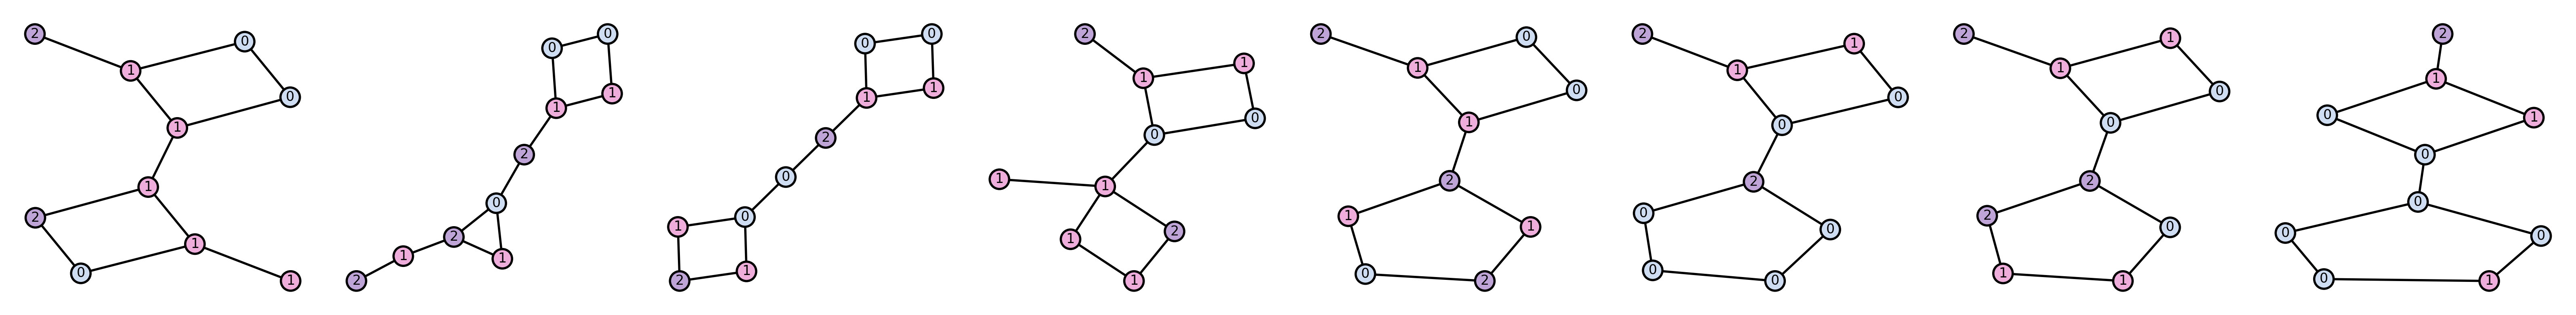

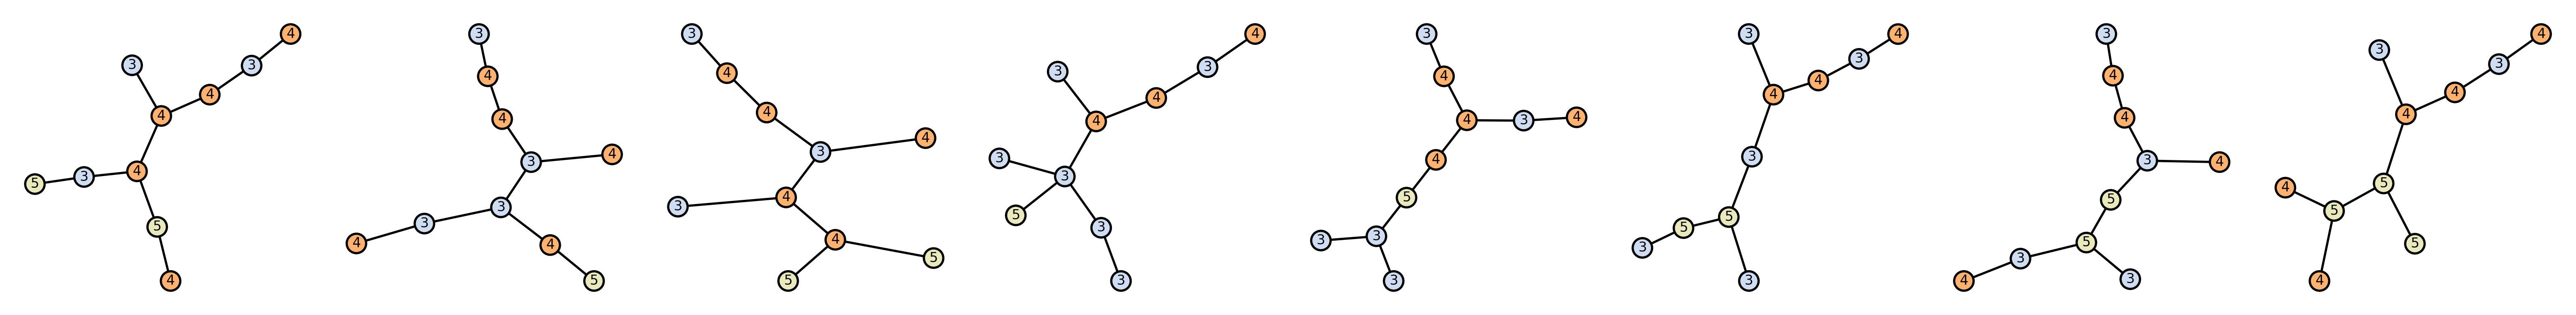

train_graphs:474   test_graphs:14


In [16]:
# Choose one dataset type and rerun this section when you change it.
DATASET_TYPE = 'ARTIFICIAL'  # Alternatives: 'ARTIFICIAL', 'MOLECULAR'

# Dataset builder bound to notebook dataset type
build_dataset = partial(_build_dataset, dataset_type=DATASET_TYPE)

# Build the dataset split and instantiate a fresh graph generator with the current configuration.
graphs, targets, train_graphs, test_graphs, train_targets, test_targets = prepare_experiment(
    build_dataset_fn=build_dataset,
    dataset_size=500,
    test_size=14,
    random_state=42,
)

graph_generator = build_graph_generator(
    # General
    verbose=2,
    nbits=12,
    # Vectorizers
    node_vectorizer_radius=2,
    node_vectorizer_distance=4,
    node_vectorizer_connector=1,
    node_vectorizer_nbits=12,
    node_vectorizer_dense=True,
    node_vectorizer_parallel=True,
    node_vectorizer_use_edges_as_features=True,
    graph_vectorizer_radius=2,
    graph_vectorizer_distance=4,
    graph_vectorizer_connector=1,
    graph_vectorizer_nbits=12,
    graph_vectorizer_dense=True,
    graph_vectorizer_parallel=True,
    graph_vectorizer_use_edges_as_features=True,
    # Feasibility
    feasibility_size_quantile=None,
    feasibility_unlabeled_radius=2,
    feasibility_valence_radius=1,
    feasibility_unlabeled_nbits=19,
    feasibility_valence_nbits=19,
    feasibility_cycle_nbits=19,
    feasibility_parallel=True,
    feasibility_backend="dill",
    # Network architecture
    latent_embedding_dimension=128,
    number_of_transformer_layers=4,
    transformer_attention_head_count=4,
    transformer_dropout=0.2,
    # Training
    learning_rate=1e-4,
    maximum_epochs=250,
    batch_size=16,
    total_steps=100,
    verbose_epoch_interval=10,
    enable_early_stopping=True,
    early_stopping_monitor="val_total",
    early_stopping_mode="min",
    early_stopping_patience=20,
    early_stopping_min_delta=100.0,
    early_stopping_ema_alpha=0.3,
    restore_best_checkpoint=True,
    important_feature_index=1,
    # Loss weights
    lambda_degree_importance=5e3,
    default_exist_pos_weight=1.0,
    lambda_node_exist_importance=0,
    lambda_node_count_importance=0.0,
    lambda_node_label_importance=5e4,
    lambda_edge_label_importance=5e3,
    lambda_direct_edge_importance=1e4,
    lambda_edge_count_importance=0.0,
    lambda_degree_edge_consistency_importance=0.0,
    lambda_auxiliary_edge_importance=1.0,
    # Sampling and guidance
    degree_temperature=1,
    pool_condition_tokens=False,
    node_field_sigma=0.2,
    sampling_step_size=0.05,
    sampling_steps=None,
    langevin_noise_scale=0.0,
    cfg_condition_dropout_prob=0.1,
    cfg_null_target_strategy="zero",
    target_classification_max_distinct=20,
    # Locality supervision and generation
    locality_horizon=1,
    locality_sample_fraction=0.5,
    negative_sample_factor=1,
    locality_sampling_strategy="stratified_preserve",
    locality_target_positive_ratio=0.5,
    use_feasibility_filtering=True,
    max_feasibility_attempts=11,
    feasibility_candidates_per_attempt=16,
    feasibility_failure_mode="return_partial",
    # Decoder
    decoder_existence_threshold=0.5,
    decoder_enforce_connectivity=True,
    decoder_degree_slack_penalty=1e6,
    decoder_warm_start_mst=True,
    decoder_n_jobs=1,
    # Outputs
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
)


In [ ]:
%%time
graph_generator = fit_graph_generator(
    graph_generator,
    train_graphs,
    resume_latest_checkpoint=True,
    checkpoint_root=CHECKPOINT_ROOT,
)


Resuming training from checkpoint: last.ckpt
/Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/node_field/ConditionalNodeFieldGenerator_9ea3d7c3df364271bfe2481faf88452e/last.ckpt
Fitting model on 474 graphs
Fitting feasibility estimator on 474 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 6 node labels detected.
  edge_labels: mode=constant, enabled. All labelled edges share one label.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.


## Save Or Resume A Fitted Generator

Saved generator filenames are intentionally short so you can copy them into a later session. This notebook uses the current Conditional Node Field artifact format.

Use the short printed filename from the save cell to restore a fitted generator later without rebuilding and refitting it.


In [ ]:
# Save the fitted generator and print a short filename that is easy to copy for later reuse.
MODEL_FILENAME = save_graph_generator(
    graph_generator,
    model_name=f"demo-{DATASET_TYPE.lower()}",
    model_dir=SAVED_GENERATOR_ROOT,
)
MODEL_FILENAME


In [ ]:
# Resume later with a copied filename from the save cell.
# list_saved_graph_generators(SAVED_GENERATOR_ROOT)
# graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


## Conditioning vs Generated Label Histograms

In [ ]:
# Compare conditioning label histograms against generated label histograms.
label_histogram_summary = run_label_histogram_analysis(graph_generator, train_graphs, n_compare=5)

### Train-Seeded Sampling
Generate samples conditioned on positive and negative training examples to inspect reconstruction behavior.


In [ ]:
# Sample graphs conditioned on training-set seeds and inspect feasibility-filtered outputs.
show_samples(n_samples=7, graphs=train_graphs, targets=train_targets, graph_generator=graph_generator)

### Test-Seeded Sampling
Repeat the same sampling view on held-out seeds to check whether behavior transfers beyond the training set.


In [ ]:
# Sample graphs conditioned on test-set seeds and inspect generalization behavior.
show_samples(n_samples=7, graphs=test_graphs, targets=test_targets, graph_generator=graph_generator)

## Positive-to-Positive Conditioning Interpolation

Select two positive training graphs at random, interpolate between them, and display the endpoints plus feasible generated graphs.

In [ ]:
# Pick two positive endpoints, interpolate between them, and decode the intermediate graphs.
selected_indices, selected_targets, endpoint_graph_a, endpoint_graph_b = sample_positive_endpoint_pair(
    train_graphs,
    train_targets,
)
print("Endpoint indices:", selected_indices)
print("Endpoint targets:", selected_targets)

display_mode = 'molecule' if DATASET_TYPE == 'MOLECULAR' else 'not_molecule'
print("Selected endpoint graphs:")
plot_networkx_graphs([endpoint_graph_a, endpoint_graph_b], n_cols=2, mode=display_mode)

interpolation_result = graph_generator.interpolate(
    endpoint_graph_a,
    endpoint_graph_b,
    k=3,
    apply_feasibility_filtering=True,
)
display(interpolation_result["summary"])

missing_steps = interpolation_result["summary"].loc[
    ~interpolation_result["summary"]["decoded"],
    "step",
].tolist()
if missing_steps:
    print("Interpolation steps rejected by feasibility filtering:", missing_steps)

graphs_to_display = [endpoint_graph_a, *interpolation_result["generated_graphs"], endpoint_graph_b]
print("Endpoints and generated interpolation graphs:")
plot_networkx_graphs(graphs_to_display, n_cols=max(1, len(graphs_to_display)), mode=display_mode)

## Real vs Generated Distribution Comparison

In [ ]:
# Compare real and generated graph distributions on the held-out test set.
distribution_comparison = compare_real_vs_generated(
    graph_generator,
    test_graphs,
    apply_feasibility_filtering=True,
)

## Stochastic Training-Embedding Sampling

Sample graph-level conditioning vectors by interpolating between pairs of cached training embeddings, then decode and display the resulting graphs.

In [ ]:
# Sample new graph-level conditions by interpolating between cached training embeddings.
display_mode = 'molecule' if DATASET_TYPE == 'MOLECULAR' else 'not_molecule'

interpolated_samples = graph_generator.sample(
    n_samples=7*4,
    interpolate_between_n_samples=10,
    apply_feasibility_filtering=True,
)

print("Feasible stochastic interpolation samples:", len(interpolated_samples))
plot_networkx_graphs(
    interpolated_samples,
    n_cols=7,
    mode=display_mode,
)


---